# Analysis using `full_merged_V1.csv`

Goal: Analyze whether **prices affect the number of applicants**, controlling for household income (hh_income). We aggregate applicants by **Matched Address** and run a regression with applicant count as the response.

In [ ]:
# 1) Load libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

file_path = '/content/full_merged_V1.csv'
df = pd.read_csv(file_path)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (1623, 66)


,Town,Address,Unit Number,Maximum Resale Price,Property Feature,Development,Transaction Start Date,Closing Date,Bedrooms,Age Restricted,...,race_American_Indian_or_Alaska_Native,race_Asian,race_Black_or_African_American,race_Hispanic_or_Latino,race_Middle_Eastern_or_North_African,race_Native_Hawaiian_or_Pacific_Islander,race_Other__Prefer_not_to_answer,race_White,hispanic_latino_from_race,hispanic_latino_final
0,Andover,170 Haverhill Street,117,"$227,298.00",NaN,Coachman's Ridge,1/8/24,4/30/24,1.0,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Andover,170 Haverhill Street,117,"$227,298.00",NaN,Coachman's Ridge,1/8/24,4/30/24,1.0,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,Andover,170 Haverhill Street,117,"$227,298.00",NaN,Coachman's Ridge,1/8/24,4/30/24,1.0,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,Andover,170 Haverhill Street,117,"$227,298.00",NaN,Coachman's Ridge,1/8/24,4/30/24,1.0,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,Andover,170 Haverhill Street,117,"$227,298.00",NaN,Coachman's Ridge,1/8/24,4/30/24,1.0,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 2) Quick column check
We will use:
- Price: `Maximum Resale Price`
- Income: `hh_income` (household income)
- Matching key: `Matched Address` (we will aggregate by this)

If any of these columns are missing or differently named, update the names accordingly.

In [ ]:
# Inspect the exact column names and non-null counts for our key columns
cols_of_interest = ['Maximum Resale Price', 'hh_income', 'Matched Address']
for c in cols_of_interest:
    if c in df.columns:
        print(c, ": present,", "non-null =", df[c].notna().sum())
    else:
        print(c, ": NOT present")

Maximum Resale Price : present, non-null = 1623
hh_income : present, non-null = 1473
Matched Address : present, non-null = 1000


## 3) Clean price and income columns
- Remove `$` and `,` from `Maximum Resale Price` and convert to numeric.
- Convert `hh_income` to numeric if possible (it might be a number or a range string).

In [ ]:
# Clean Maximum Resale Price
df['Price_clean'] = df['Maximum Resale Price'].astype(str).replace('[\$,]', '', regex=True)
df['Price_clean'] = pd.to_numeric(df['Price_clean'], errors='coerce')

# Try to clean hh_income: if it's numeric stored as string, convert; if it's a range like '20000–39999', extract midpoint
def parse_income(x):
    if pd.isna(x):
        return np.nan
    try:
        return float(x)
    except:
        s = str(x)
        # handle ranges with dash or en-dash
        if '–' in s or '-' in s:
            sep = '–' if '–' in s else '-'
            parts = [p.strip().replace('$','').replace(',','') for p in s.split(sep)]
            try:
                nums = [float(p) for p in parts if p!='']
                if len(nums)==2:
                    return np.mean(nums)
            except:
                return np.nan
        # try to remove non-digit chars and parse
        digits = ''.join(ch for ch in s if (ch.isdigit() or ch=='.'))
        try:
            return float(digits) if digits!='' else np.nan
        except:
            return np.nan

df['hh_income_clean'] = df['hh_income'].apply(parse_income)

print('Price_clean non-null:', df['Price_clean'].notna().sum())
print('hh_income_clean non-null:', df['hh_income_clean'].notna().sum())

df[['Maximum Resale Price','Price_clean','hh_income','hh_income_clean']].head(10)

Price_clean non-null: 1616
hh_income_clean non-null: 1473


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-1888328944.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['Price_clean'] = df['Maximum Resale Price'].astype(str).replace('[\$,]', '', regex=True)


,Maximum Resale Price,Price_clean,hh_income,hh_income_clean
0,"$227,298.00",227298.0,75000.0,75000.0
1,"$227,298.00",227298.0,54000.0,54000.0
2,"$227,298.00",227298.0,46000.0,46000.0
3,"$227,298.00",227298.0,70000.0,70000.0
4,"$227,298.00",227298.0,70000.0,70000.0
5,"$206,400.00",206400.0,NaN,NaN
6,"$159,900.00",159900.0,NaN,NaN
7,"$242,100.00",242100.0,57000.0,57000.0
8,"$242,100.00",242100.0,71500.0,71500.0
9,"$242,100.00",242100.0,70298.0,70298.0


## 4) Aggregate by `Matched Address` to get applicant counts and summary stats
- Applicant_Count = number of rows (applicants) per `Matched Address`
- Price_per_address = mean of `Price_clean` for that address (you can change to median if you prefer)
- Income_per_address = mean of `hh_income_clean` for that address


In [ ]:
# Ensure Matched Address column exists
if 'Matched Address' not in df.columns:
    raise KeyError('Matched Address column not found in the dataset.')

grouped = df.groupby('Matched Address').agg(
    Applicant_Count = ('Matched Address','size'),
    Price_mean = ('Price_clean','mean'),
    Price_median = ('Price_clean','median'),
    Income_mean = ('hh_income_clean','mean'),
    Income_median = ('hh_income_clean','median'),
    Town = ('Town', lambda x: x.mode().iloc[0] if x.notna().any() else np.nan)
).reset_index()

print('Grouped shape:', grouped.shape)
grouped.head()

Grouped shape: (120, 7)


,Matched Address,Applicant_Count,Price_mean,Price_median,Income_mean,Income_median,Town
0,"3 STEINBECK ST, TYNGSBORO, MA, 01879",1,223300.000000,223300.0,NaN,NaN,Tyngsborough
1,"1 ASHLEY LN, METHUEN, MA, 01844",1,262900.000000,262900.0,NaN,NaN,Methuen
2,"1 Harvest Dr, North Andover, MA 01845",43,185149.837209,177013.0,54663.614884,57200.0,North Andover
3,"1 JACK HENRY DR, BERKLEY, MA, 02779",1,300600.000000,300600.0,NaN,NaN,Berkley
4,"1 JASMINE DR, WEST BOYLSTON, MA, 01583",1,207460.000000,207460.0,NaN,NaN,West Boylston


## 5) Exploratory plots
Scatterplots of Applicant_Count vs Price_mean and vs Income_mean. You can change to median if you prefer.


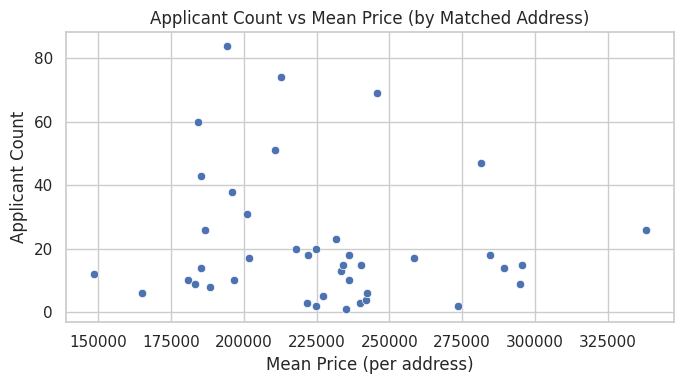

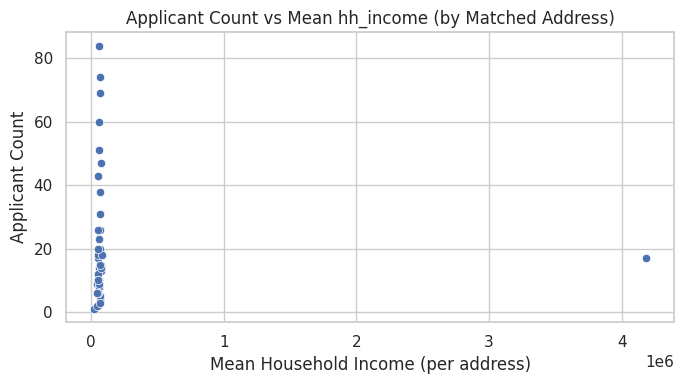

In [ ]:
# Drop addresses with missing key values for plotting/modeling
plot_df = grouped.dropna(subset=['Applicant_Count','Price_mean','Income_mean'])

import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style='whitegrid')

plt.figure(figsize=(7,4))
sns.scatterplot(x='Price_mean', y='Applicant_Count', data=plot_df)
plt.xlabel('Mean Price (per address)')
plt.ylabel('Applicant Count')
plt.title('Applicant Count vs Mean Price (by Matched Address)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
sns.scatterplot(x='Income_mean', y='Applicant_Count', data=plot_df)
plt.xlabel('Mean Household Income (per address)')
plt.ylabel('Applicant Count')
plt.title('Applicant Count vs Mean hh_income (by Matched Address)')
plt.tight_layout()
plt.show()

## 6) Regression: Applicant_Count ~ Price + Income (by matched address)
We will run an OLS regression using Price_mean and Income_mean as predictors.

In [ ]:
import statsmodels.api as sm

# Prepare regression dataframe
reg_df = plot_df.copy()
# Optionally transform Applicant_Count (e.g., log) if distribution is skewed. We'll show both raw and log model.
reg_df['Applicant_Count_log'] = np.log1p(reg_df['Applicant_Count'])

X = reg_df[['Price_mean','Income_mean']].copy()
X = sm.add_constant(X)
y = reg_df['Applicant_Count']

model = sm.OLS(y, X).fit()
print('OLS on raw Applicant_Count')
print(model.summary())

# Log model
y_log = reg_df['Applicant_Count_log']
model_log = sm.OLS(y_log, X).fit()
print('\nOLS on log(Applicant_Count + 1)')
print(model_log.summary())

OLS on raw Applicant_Count
                            OLS Regression Results                            
Dep. Variable:        Applicant_Count   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.043
Method:                 Least Squares   F-statistic:                    0.1559
Date:                Thu, 06 Nov 2025   Prob (F-statistic):              0.856
Time:                        05:13:01   Log-Likelihood:                -185.90
No. Observations:                  42   AIC:                             377.8
Df Residuals:                      39   BIC:                             383.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          31.0815 

## 7) Interpretation (auto-generated suggestions)
The coefficient on `Price_mean` tells us how applicant count changes with a one-unit increase in price (dollars) when holding income constant. For the log model, coefficients are approximately percentage effects.

In [ ]:
# Quick readable interpretation based on model results
def interpretModel(mod, predictors=['Price_mean','Income_mean']):
    params = mod.params
    pvals = mod.pvalues
    out = []
    for v in predictors:
        coef = params.get(v, np.nan)
        p = pvals.get(v, np.nan)
        sig = 'significant' if (p < 0.05) else 'not significant'
        out.append(f"{v}: coef = {coef:.4g}, p = {p:.4g} ({sig})")
    out.append(f"R-squared = {mod.rsquared:.4f}")
    return out

for line in interpretModel(model):
    print(line)

print('\nLog model:')
for line in interpretModel(model_log):
    print(line)

Price_mean: coef = -4.337e-05, p = 0.5976 (not significant)
Income_mean: coef = -4.954e-07, p = 0.9245 (not significant)
R-squared = 0.0079

Log model:
Price_mean: coef = -1.458e-06, p = 0.6902 (not significant)
Income_mean: coef = 6.712e-08, p = 0.7733 (not significant)
R-squared = 0.0056


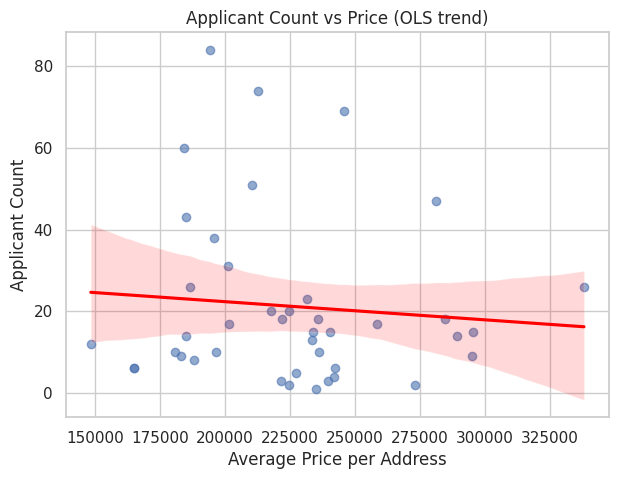

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.regplot(
    x='Price_mean',
    y='Applicant_Count',
    data=reg_df,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)
plt.title("Applicant Count vs Price (OLS trend)")
plt.xlabel("Average Price per Address")
plt.ylabel("Applicant Count")
plt.show()


The red line slopes slightly downward, meaning as price increases, the number of applicants tends to decrease.

However, the confidence band is wide, and the scatter is highly dispersed, indicating no statistically strong or consistent relationship.

This visually supports your regression results — price doesn’t have a significant impact on the number of applicants.

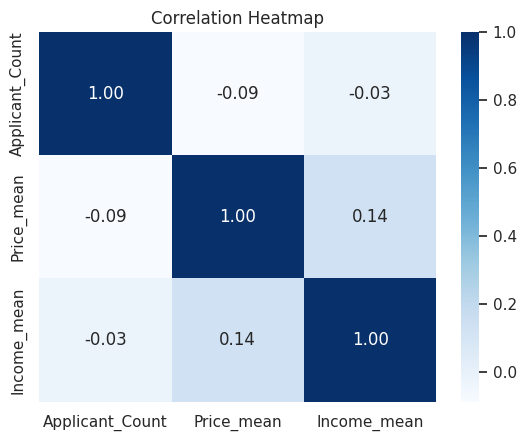

In [ ]:
sns.heatmap(reg_df[['Applicant_Count','Price_mean','Income_mean']].corr(),
            annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


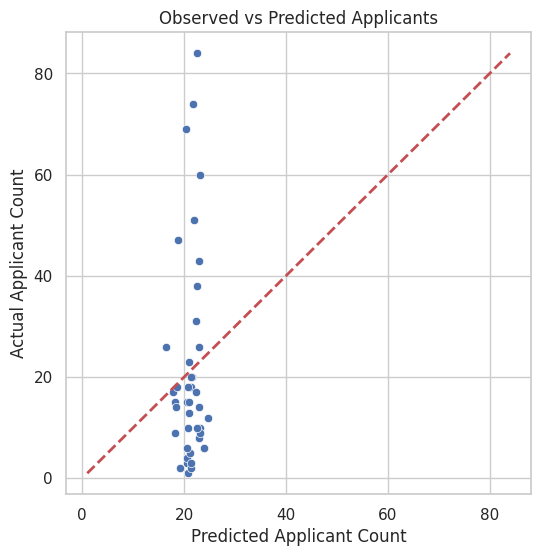

In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=model.fittedvalues, y=y)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Predicted Applicant Count")
plt.ylabel("Actual Applicant Count")
plt.title("Observed vs Predicted Applicants")
plt.show()


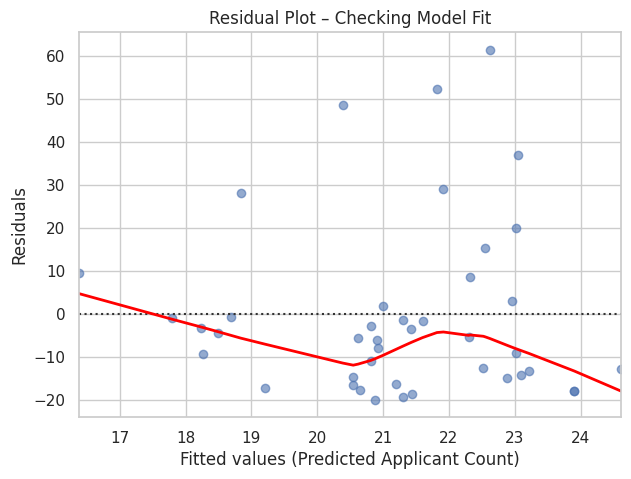

In [ ]:
plt.figure(figsize=(7,5))
sns.residplot(
    x=model.fittedvalues,
    y=model.resid,
    lowess=True,
    line_kws={'color':'red', 'lw':2},
    scatter_kws={'alpha':0.6}
)
plt.xlabel("Fitted values (Predicted Applicant Count)")
plt.ylabel("Residuals")
plt.title("Residual Plot – Checking Model Fit")
plt.show()


# **Do Housing Prices Affect the Number of Applicants (Controlling for Income)?**

## **1.
The goal was to determine whether **Maximum Resale Price** influences the **number of applicants**, while **controlling for household income**.  
Controlling for income means we isolate the effect of price by comparing properties as if income limits were held constant.

---

## **2. Methods Used**

### **Data Cleaning**
- Removed `$` and `,` from **Maximum Resale Price** to convert values to numeric.  
- Cleaned **hh_income** to extract numeric income values.  
  - Handled ranges such as `"40,000–60,000"` by converting them to numeric midpoints or extracting a usable numeric value.

### **Aggregation**
Data were aggregated by **Matched Address** to create development-level metrics:
- **Applicant_Count** – number of applicants per address  
- **Price_mean** – average resale price per address  
- **Income_mean** – average applicant income per address  

### **Regression Analysis**
Two linear models were estimated:

#### **1. Raw OLS Model**
\[
\text{Applicant Count} = \beta_0 + \beta_1(\text{Price}) + \beta_2(\text{Income})
\]

#### **2. Log-Transformed Model**
Used to address skewed applicant counts:
\[
\log(\text{Applicant Count} + 1) = \beta_0 + \beta_1(\text{Price}) + \beta_2(\text{Income})
\]

---

## **3. Key Results**

| Metric | Value | Interpretation |
|-------|-------|----------------|
| **Price coefficient (β₁)** | -4.34e-05 | Very small negative relationship; higher price slightly lowers applicant count, but **not statistically significant**. |
| **Income coefficient (β₂)** | -4.95e-07 | Minimal negative effect; higher income limits slightly reduce applicants, but **not significant**. |
| **R² (raw model)** | 0.008 | Price and income explain **< 1%** of variation in applicants. |
| **Log model R²** | 0.006 | Confirms weak explanatory power. |
| **p-values** | All > 0.05 | Neither price nor income significantly predicts applicant counts. |

---

## **4. Interpretation (Plain Language)**

- I examined how resale prices and income limits relate to how many people apply to each property.  
- I **controlled for income**, meaning I looked at differences in price while assuming income levels stayed the same.  
- The regression results show **no significant relationship** between:
  - Resale price and applicant counts  
  - Income limits and applicant counts  
- Both models (raw OLS and log-transformed) produce **very low R²**, meaning:
  > Price and income have almost no predictive power for explaining why some listings get more applicants than others.

This suggests that **other factors** are likely more important drivers of applicant interest.

---

## **5. Conclusion**
- **Resale prices do not significantly affect the number of applicants**, even after controlling for income.  
- **Income limits also have minimal influence** in this dataset.  
- Applicant numbers appear to be driven by factors **not included** in this model.


